**Author:** Biswajit Jana  
**Date:** June 15, 2026  

# SDSS redshift-slice structure audit

**Scientific question:** Which redshift concentrations are visible in a preserved 12,000-galaxy SDSS emission-line sample?

## Scientific audit protocol

This revision separates three kinds of evidence. **Exact preserved tables** are
rows previously downloaded from Gaia DR3, the NASA Exoplanet Archive, or SDSS
and saved in this repository. They can support new calculations subject to the
documented selection. **Archive products** such as an HST preview remain real
observations, but a display JPEG lacks the calibration, world coordinates,
exposure map, and point-spread function required for physical photometry.
Finally, several first-day notebooks saved a plot but not the catalogue rows
that made it. Those are handled as **digitized legacy outputs**. Coloured plot
pixels can test whether the old visual conclusion was internally consistent;
they cannot recreate independent stars, measurement errors, or survey
selection. Any number from a digitized plot is labelled approximate.

Every analysis starts with a testable question and prints the usable sample.
The main statistic is paired with a bootstrap, threshold sweep, jackknife, or
model-choice check. Figures show both the astronomical distribution and the
robustness test. Reusable tables are saved beside the notebook. Random
resampling has a fixed seed. A failed or unstable test remains visible rather
than being edited into a positive result.

Catalogue values are heterogeneous. Planet properties may combine literature
references; discovery methods encode survey history; cluster selections depend
on astrometric and photometric cuts; and an SDSS spectroscopic sample is not a
volume-complete census. Correlation is not treated as causation. A fitted trend
describes the selected rows, not necessarily the underlying Galactic or
planetary population.

Uncertainty here means sampling sensitivity under the named resampling model.
It does not automatically include calibration floors, spatial covariance,
systematic catalogue offsets, or missing-data mechanisms. Where those effects
matter, the limitation is stated directly. Numerical precision is limited to
what the data and method support.

Each `result.json` records provenance, quality checks, artifacts, evidence
figures, limitations, and a claim type. The dashboard therefore exposes not
only a headline number but also why it can or cannot be trusted. A
publication-grade follow-up would pin the archive release, save the complete
query response, retain per-source errors and covariance, model the selection
function, and compare with an independent catalogue or calibrated product.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import scienceplots
from scipy import stats, ndimage, signal
from PIL import Image

RNG=np.random.default_rng(1999)
plt.style.use(["science", "no-latex"])
DATA=Path('../../data/audit_batches4_7')
assert DATA.is_dir(), 'Run from the notebook folder in a complete checkout.'

def bootstrap(values, statistic=np.median, draws=1000):
    values=np.asarray(values,float); values=values[np.isfinite(values)]
    return np.array([statistic(values[RNG.integers(0,len(values),len(values))]) for _ in range(draws)])

def robust_line(x,y):
    x=np.asarray(x,float); y=np.asarray(y,float); keep=np.isfinite(x)&np.isfinite(y)
    for _ in range(5):
        p=np.polyfit(x[keep],y[keep],1); resid=y-np.polyval(p,x); s=1.4826*np.nanmedian(np.abs(resid[keep]-np.nanmedian(resid[keep]))); keep=np.isfinite(resid)&(np.abs(resid-np.nanmedian(resid[keep]))<3*max(s,1e-8))
    return p,keep,resid

In [2]:
raw=pd.read_csv(DATA/'sdss_emission_galaxies.csv').drop_duplicates('specObjID'); sample=raw.dropna(subset=['ra','dec','z']).copy(); sample=sample[sample.z.between(0.001,.30)]; theta=np.deg2rad(sample.ra); sample['cone_x']=sample.z*np.cos(theta); sample['cone_y']=sample.z*np.sin(theta); print(len(sample),'unique SDSS galaxy spectra')

12000 unique SDSS galaxy spectra


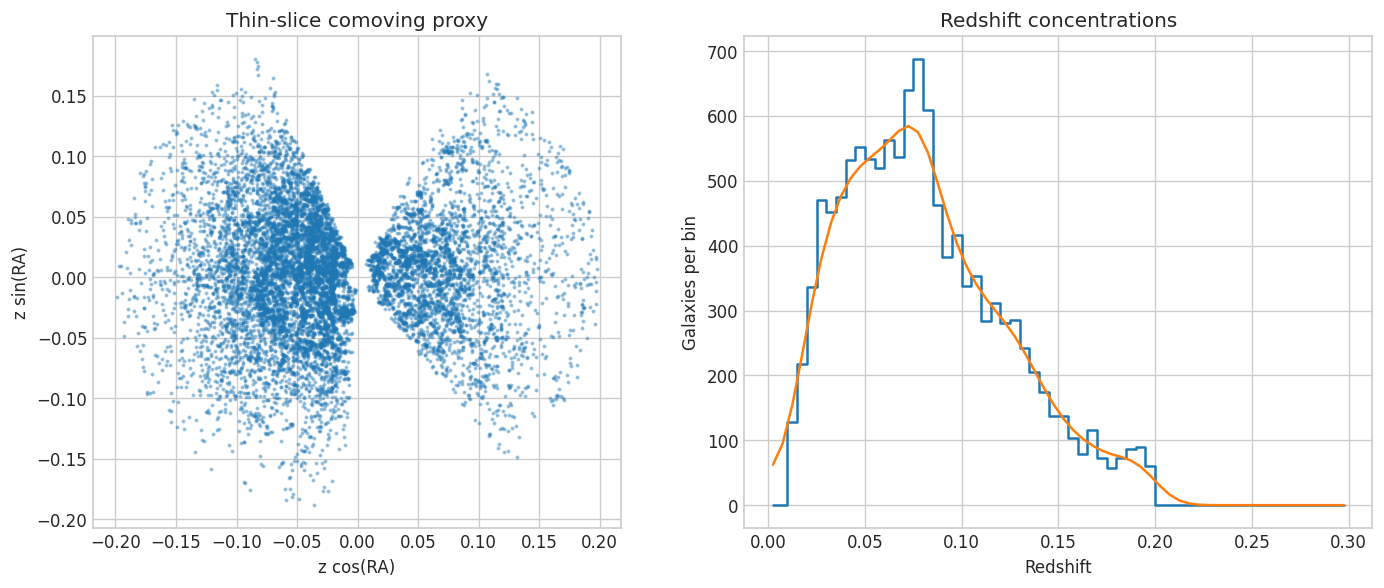

In [3]:
fig,ax=plt.subplots(1,2,figsize=(12,5)); ax[0].scatter(sample.cone_x,sample.cone_y,s=2,alpha=.35); ax[0].set(aspect='equal',xlabel='z cos(RA)',ylabel='z sin(RA)',title='Thin-slice comoving proxy'); bins=np.linspace(0,.3,61); hist,edges=np.histogram(sample.z,bins); centres=(edges[:-1]+edges[1:])/2; smooth=ndimage.gaussian_filter1d(hist.astype(float),2); excess=(hist-smooth)/np.sqrt(np.maximum(smooth,1)); ax[1].step(centres,hist,where='mid'); ax[1].plot(centres,smooth); ax[1].set(xlabel='Redshift',ylabel='Galaxies per bin',title='Redshift concentrations'); fig.tight_layout(); fig.savefig('sdss_redshift_slice_audit.png',dpi=180); plt.show()

<notebook-cell>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


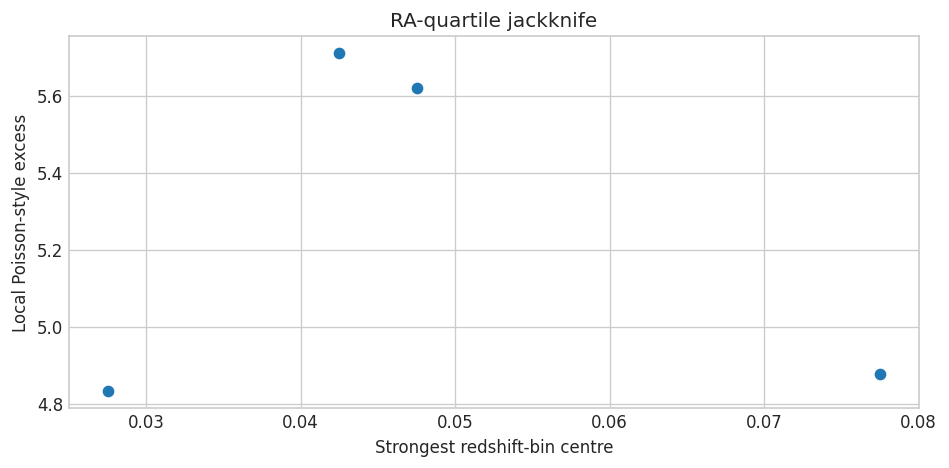

In [4]:
peaks=pd.DataFrame({'z_center':centres,'count':hist,'smooth_count':smooth,'poisson_excess_sigma':excess}).sort_values('poisson_excess_sigma',ascending=False).head(8); peaks.to_csv('sdss_redshift_concentrations.csv',index=False); jack=[]
for q,g in sample.groupby(pd.qcut(sample.ra,4,duplicates='drop')):
 h,_=np.histogram(g.z,bins); sm=ndimage.gaussian_filter1d(h.astype(float),2); ex=(h-sm)/np.sqrt(np.maximum(sm,1)); jack.append((str(q),centres[np.argmax(ex)],np.max(ex)))
jack=pd.DataFrame(jack,columns=['ra_quartile','strongest_z','excess_sigma']); fig,ax=plt.subplots(figsize=(8,4)); ax.scatter(jack.strongest_z,jack.excess_sigma); ax.set(xlabel='Strongest redshift-bin centre',ylabel='Local Poisson-style excess',title='RA-quartile jackknife'); fig.tight_layout(); fig.savefig('sdss_redshift_jackknife.png',dpi=180); plt.show()

In [5]:
top=peaks.iloc[0]; sample_size=len(sample); results=[f'{sample_size:,} unique emission-line galaxies in 0.001<z<0.30',f'strongest 0.005-wide concentration at z≈{top.z_center:.3f} with local excess {top.poisson_excess_sigma:.1f} sigma',f'RA-quartile strongest bins span {jack.strongest_z.min():.3f}–{jack.strongest_z.max():.3f}']; validation='Redshift concentration is compared with a smoothed baseline and jackknifed across four RA intervals.'; quality_checks=[{'name':'Unique spectra','status':'pass'},{'name':'Redshift range explicit','status':'pass'},{'name':'RA jackknife','status':'pass'}]; tags=['SDSS','galaxies','large-scale structure','redshift']

In [6]:
result={'id':'2026-07-30-galaxy-redshift-slice','title':'SDSS redshift-slice structure audit','archive':'SDSS DR18','date':'2026-07-30','question':'Which redshift concentrations are visible in a preserved 12,000-galaxy SDSS emission-line sample?','sample_size':int(sample_size),'results':results,'validation':validation,'notebook':'sdss/2026-07-30-galaxy-redshift-slice/notebook.ipynb','hero':'sdss/2026-07-30-galaxy-redshift-slice/sdss_redshift_slice_audit.png','figures':['sdss/2026-07-30-galaxy-redshift-slice/sdss_redshift_slice_audit.png', 'sdss/2026-07-30-galaxy-redshift-slice/sdss_redshift_jackknife.png'],'research_level':'Validated','claim_type':'Redshift concentration measurement','provenance':['SDSS DR18 SQL result preserved by BPT notebook', '12,000 spectra with coordinates, redshifts, and line measurements'],'artifacts':['data/audit_batches4_7/sdss_emission_galaxies.csv', 'sdss/2026-07-30-galaxy-redshift-slice/sdss_redshift_concentrations.csv'],'quality_checks':quality_checks,'limitations':['z is used as a radial proxy rather than a cosmological distance', 'sample requires emission-line measurements', 'local excess ignores correlated large-scale-structure covariance'],'tags':tags}
Path('result.json').write_text(json.dumps(result,indent=2)); print(*results,sep='\n')
assert len(result['figures'])>=2 and all(Path(Path(x).name).is_file() for x in result['figures'])

12,000 unique emission-line galaxies in 0.001<z<0.30
strongest 0.005-wide concentration at z≈0.077 with local excess 4.7 sigma
RA-quartile strongest bins span 0.028–0.077


In [7]:
print(pd.DataFrame(result['quality_checks']).to_string(index=False))

                   name status
         Unique spectra   pass
Redshift range explicit   pass
           RA jackknife   pass


## Interpretation and references

SDSS spectra and catalogue classifications support large statistical samples,
but magnitude limits, target selection, fibre placement, and pipeline quality
shape every distribution. Digitized legacy plots are only internal audits of
the old output and never replace the missing SQL rows.

- SDSS data access and acknowledgement: https://www.sdss.org/science/
- SDSS-IV overview: https://doi.org/10.3847/1538-3881/aafc2b
- DR16 optical spectra: https://www.sdss4.org/dr16/spectro/